# EfficientNet-B0 with 5-Fold Cross Validation

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms, models
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# set random seeds for reproducibility
RANDOM_STATE = 8
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# check what device we're using
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f"Using device: MPS (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    print(f"Using device: CPU")

print(f"PyTorch version: {torch.__version__}")

Using device: CUDA
PyTorch version: 2.9.0+cu130


## Configuration

Hyperparameters, etc

In [ ]:
# paths and basic setup
DATASET_DIR = Path('../../data/images')
IMAGE_SIZE = 224
N_FOLDS = 5
TEST_RATIO = 0.2  # Hold out 20% for test set

# training hyperparameters
BATCH_SIZE = 32
EPOCHS = 150
LEARNING_RATE = 0.0020594007612475913
WEIGHT_DECAY = 1.0083970230770894e-05
PATIENCE = 25

# focal loss parameters
FOCAL_ALPHA = 1.0
FOCAL_GAMMA = 1.2483412017424098

# mixup parameter
MIXUP_ALPHA = 0.4
USE_MIXUP = False

# Best hyperparameters from optimization
HYPERPARAMETERS = {
    'cnn_dropout1': 0.6217843386251581,
    'cnn_dropout2': 0.19498440140497733,
    'cnn_learning_rate': 0.0004303702377686196,
    'cnn_batch_size': 16,
    'cnn_weight_decay': 4.572988042665251e-06,
    'cnn_focal_gamma': 1.2483412017424098
}

## Data Augmentation

The images are melting curve graphs with temperature on the x-axis and fluorescense on the y-axis, so transformations were carefully chosen.
- resize to 224x224
- small vertical shifts
- small brightness and contrast jitter
- small gaussian noise
- normalize to the standard ImageNet normaliztion

In [3]:
class AddGaussianNoise(object):
    def __init__(self, std=0.005):
        self.std = std
    
    def __call__(self, tensor):
        # add a small random value to each pixel in the image
        return tensor + torch.randn_like(tensor) * self.std

def get_transforms(is_training=True):
    if is_training:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomAffine(degrees=0, translate=(0.0, 0.03)), # small vertical shift only
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            AddGaussianNoise(std=0.005), # measurement noise
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        # no augmentation for validation/test
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

## Model Architecture

EfficientNet-B0 pretrained on ImageNet, then fine tuned for the 57 shark species

In [4]:
def get_model(num_classes, hyperparams=None):
    if hyperparams is None:
        hyperparams = HYPERPARAMETERS
    
    # Load pretrained EfficientNet-B0 backbone
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    
    # Get the input features from the features layer
    in_features = model.classifier[1].in_features
    
    # Build custom classifier head with cnn_dropout1 and cnn_dropout2
    classifier_layers = nn.Sequential(
        nn.Dropout(hyperparams['cnn_dropout1']),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(hyperparams['cnn_dropout2']),
        nn.Linear(256, num_classes)
    )
    
    # Replace the classifier
    model.classifier = classifier_layers
    
    return model

## Loss Function

Focal loss is better than CE when there is a class imabalance.

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

## Training Functions

Training loop

In [6]:
def train_epoch(model, loader, criterion, optimizer, device, use_mixup=False):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # forward pass
        optimizer.zero_grad()
        outputs = model(inputs)

        # measure loss
        loss = criterion(outputs, labels)
        
        # backward pass 
        loss.backward()
        optimizer.step()
        
        # accumulate metrics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # predict
            outputs = model(inputs)

            # measure loss
            loss = criterion(outputs, labels)
            
            # accumulate metrics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = 100. * accuracy_score(all_labels, all_preds)
    f1 = 100. * f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = 100. * precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = 100. * recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return running_loss / len(loader), accuracy, f1, precision, recall, all_preds, all_labels

## Load Dataset

In [ ]:
# load the full dataset from single images folder
train_transform = get_transforms(is_training=True)
test_transform = get_transforms(is_training=False)

# Load all images
full_dataset = datasets.ImageFolder(DATASET_DIR, transform=train_transform)

# get labels for stratified splitting
labels = np.array([label for _, label in full_dataset])
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

print(f"Full dataset: {len(full_dataset)} samples")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names[:5]}... (showing first 5)")

# Split into train+val and test sets (80/20 stratified split)
from sklearn.model_selection import train_test_split
train_val_indices, test_indices = train_test_split(
    np.arange(len(full_dataset)),
    test_size=TEST_RATIO,
    stratify=labels,
    random_state=RANDOM_STATE
)

# Create test dataset
test_dataset = torch.utils.data.Subset(full_dataset, test_indices)
# Create a copy of full_dataset with test_transform for testing
test_dataset_no_aug = datasets.ImageFolder(DATASET_DIR, transform=test_transform)
test_dataset = torch.utils.data.Subset(test_dataset_no_aug, test_indices)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nTrain+Val set: {len(train_val_indices)} samples")
print(f"Test set: {len(test_indices)} samples")
print(f"Test set: {len(test_dataset)} samples")

## 5-Fold Cross Validation Training

Train a different model on each split of the data and save each one

In [ ]:
# storage for results
fold_results = []
fold_metrics = []  # Store all metrics for each fold
all_histories = [] # store training history for each fold

# k-fold cross validation on train+val set only
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
train_val_labels = labels[train_val_indices]

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(train_val_labels)), train_val_labels)):
    print(f"\n{'='*70}")
    print(f"Fold {fold + 1}/{N_FOLDS}")
    print('='*70)
    
    # Map back to full dataset indices
    fold_train_indices = train_val_indices[train_idx]
    fold_val_indices = train_val_indices[val_idx]
    
    # create data loaders for this fold
    train_sampler = SubsetRandomSampler(fold_train_indices)
    val_sampler = SubsetRandomSampler(fold_val_indices)
    
    train_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0)
    val_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, sampler=val_sampler, num_workers=0)
    
    # initialize model
    model = get_model(num_classes).to(DEVICE)
    
    # loss, optimizer, scheduler
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    
    # tracking
    best_val_acc = 0.0
    best_model_state = None
    best_val_metrics = None
    patience_counter = 0
    
    # history for this fold
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'val_f1': [],
        'val_precision': [],
        'val_recall': [],
        'learning_rates': []
    }
    
    # training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE, USE_MIXUP)
        val_loss, val_acc, val_f1, val_precision, val_recall, val_preds, val_labels = validate(model, val_loader, criterion, DEVICE)
        
        # store metrics
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])
        
        scheduler.step()
        
        # check if this is the best model so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            best_val_metrics = {
                'accuracy': val_acc,
                'f1': val_f1,
                'precision': val_precision,
                'recall': val_recall
            }
            patience_counter = 0
        else:
            patience_counter += 1
        
        # print progress every 10 epochs
        if epoch % 10 == 0 or epoch == EPOCHS - 1:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
                  f"Val Acc: {val_acc:.2f}% F1: {val_f1:.2f}% P: {val_precision:.2f}% R: {val_recall:.2f}%")
        
        # early stopping
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # save results for this fold
    fold_results.append(best_val_acc)
    fold_metrics.append(best_val_metrics)
    all_histories.append(history)
    
    print(f"\nFold {fold+1} Best Validation Metrics:")
    print(f"  Accuracy: {best_val_metrics['accuracy']:.2f}%")
    print(f"  F1-Score: {best_val_metrics['f1']:.2f}%")
    print(f"  Precision: {best_val_metrics['precision']:.2f}%")
    print(f"  Recall: {best_val_metrics['recall']:.2f}%")
    
    # save the best model for this fold
    if best_model_state:
        # Format accuracy as 4-digit string (e.g., 98.84% -> 9884)
        acc_str = f"{best_val_acc:.2f}".replace('.', '')
        filename = f'efficientnet_b0_fold{fold+1}_{acc_str}.pth'
        torch.save({
            'model_state_dict': best_model_state,
            'fold': fold,
            'val_acc': best_val_acc,
            'val_metrics': best_val_metrics,
            'history': history
        }, filename)
        print(f"Model saved to {filename}")

# final k-fold results
mean_acc = np.mean(fold_results)
std_acc = np.std(fold_results)

print(f"\n{'='*70}")
print("5-Fold Cross Validation Results")
print('='*70)
print(f"{'Fold':<8} {'Accuracy':<12} {'F1-Score':<12} {'Precision':<12} {'Recall':<12}")
print('-'*70)
for fold_idx in range(N_FOLDS):
    print(f"Fold {fold_idx+1:<3} {fold_metrics[fold_idx]['accuracy']:>10.2f}% "
          f"{fold_metrics[fold_idx]['f1']:>10.2f}% "
          f"{fold_metrics[fold_idx]['precision']:>10.2f}% "
          f"{fold_metrics[fold_idx]['recall']:>10.2f}%")
print('-'*70)
print(f"Mean   {np.mean([m['accuracy'] for m in fold_metrics]):>10.2f}% "
      f"{np.mean([m['f1'] for m in fold_metrics]):>10.2f}% "
      f"{np.mean([m['precision'] for m in fold_metrics]):>10.2f}% "
      f"{np.mean([m['recall'] for m in fold_metrics]):>10.2f}%")
print(f"Std    {np.std([m['accuracy'] for m in fold_metrics]):>10.2f}% "
      f"{np.std([m['f1'] for m in fold_metrics]):>10.2f}% "
      f"{np.std([m['precision'] for m in fold_metrics]):>10.2f}% "
      f"{np.std([m['recall'] for m in fold_metrics]):>10.2f}%")
print('='*70)

## Test Set Evaluation

Evaluate each fold on the test set and compare results.

In [ ]:
# Test set already loaded above in the "Load Dataset" section

print(f"Test set: {len(test_dataset)} samples")

def test_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # forward pass
            outputs = torch.softmax(model(images), dim=1)
            _, predicted = outputs.max(1)
            
            # accumulate statistics
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            # store predictions
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    accuracy = 100. * accuracy_score(all_labels, all_preds)
    f1 = 100. * f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    precision = 100. * precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = 100. * recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return accuracy, f1, precision, recall, all_preds, all_labels

# test each fold
print("\nTesting individual folds on held-out test set:")
individual_test_accs = []
individual_test_metrics = []
best_test_fold = 0
best_test_acc = 0

for fold in range(N_FOLDS):
    model = get_model(num_classes).to(DEVICE)
    # Find the model file for this fold (it has the accuracy in the name)
    import glob
    model_files = glob.glob(f'efficientnet_b0_fold{fold+1}_*.pth')
    if model_files:
        checkpoint = torch.load(model_files[0], map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        fold_val_acc = checkpoint['val_acc']
        fold_val_metrics = checkpoint['val_metrics']

        test_acc, test_f1, test_precision, test_recall, _, _ = test_model(model, test_loader, DEVICE)
        individual_test_accs.append(test_acc)
        individual_test_metrics.append({
            'accuracy': test_acc,
            'f1': test_f1,
            'precision': test_precision,
            'recall': test_recall
        })
        
        print(f"Fold {fold+1} (Val: {fold_val_acc:.2f}%) - Test: Acc: {test_acc:.2f}% F1: {test_f1:.2f}% P: {test_precision:.2f}% R: {test_recall:.2f}%")
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_test_fold = fold
    else:
        print(f"Warning: Could not find model file for fold {fold+1}")

print(f"\n{'='*70}")
print(f"Best individual fold: Fold {best_test_fold + 1} with {best_test_acc:.2f}% accuracy")
print(f"Test Metrics for Best Fold:")
print(f"  Accuracy: {individual_test_metrics[best_test_fold]['accuracy']:.2f}%")
print(f"  F1-Score: {individual_test_metrics[best_test_fold]['f1']:.2f}%")
print(f"  Precision: {individual_test_metrics[best_test_fold]['precision']:.2f}%")
print(f"  Recall: {individual_test_metrics[best_test_fold]['recall']:.2f}%")
print('='*70)

## Training Curves

Let's visualize how training progressed for each fold.

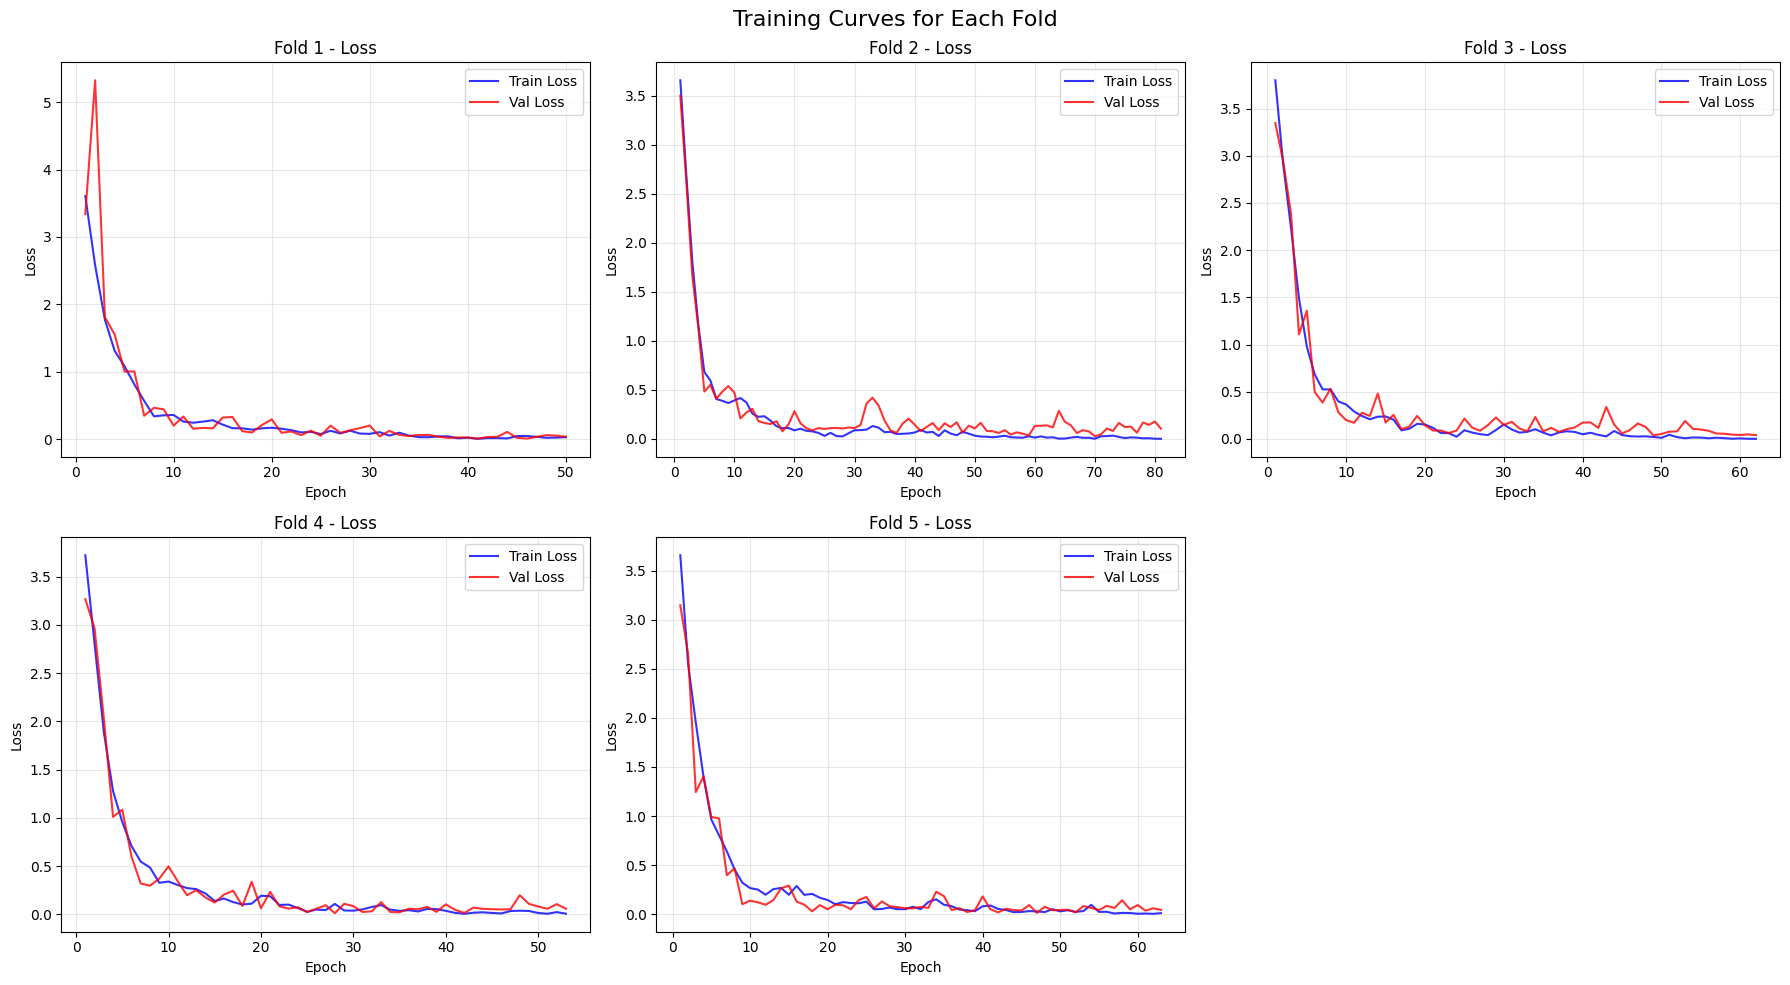

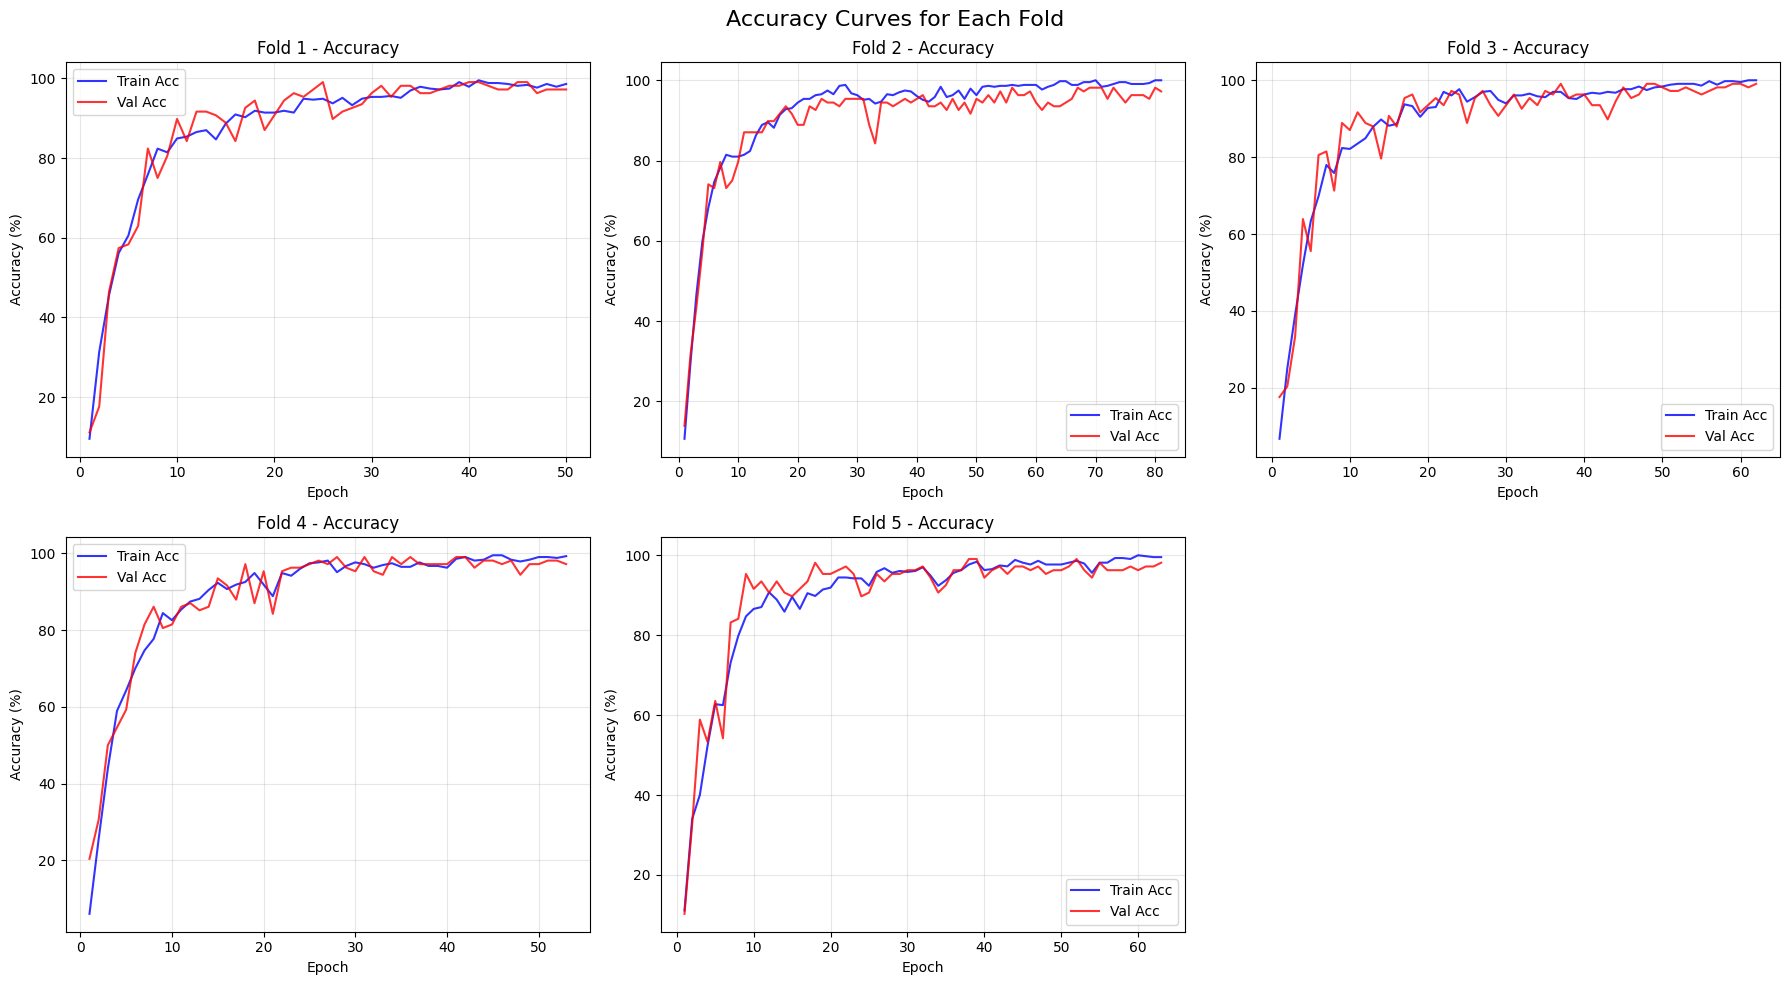

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves for Each Fold', fontsize=16)

# plot loss curves
for fold_idx, history in enumerate(all_histories):
    ax = axes[0, fold_idx % 3] if fold_idx < 3 else axes[1, fold_idx % 3]
    
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', alpha=0.8)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'Fold {fold_idx + 1} - Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

# remove extra subplot
if N_FOLDS == 5:
    fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# plot accuracy curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Accuracy Curves for Each Fold', fontsize=16)

for fold_idx, history in enumerate(all_histories):
    ax = axes[0, fold_idx % 3] if fold_idx < 3 else axes[1, fold_idx % 3]
    
    epochs = range(1, len(history['train_acc']) + 1)
    ax.plot(epochs, history['train_acc'], 'b-', label='Train Acc', alpha=0.8)
    ax.plot(epochs, history['val_acc'], 'r-', label='Val Acc', alpha=0.8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Fold {fold_idx + 1} - Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

if N_FOLDS == 5:
    fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.savefig('training_accuracy_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Learning Rate Schedule

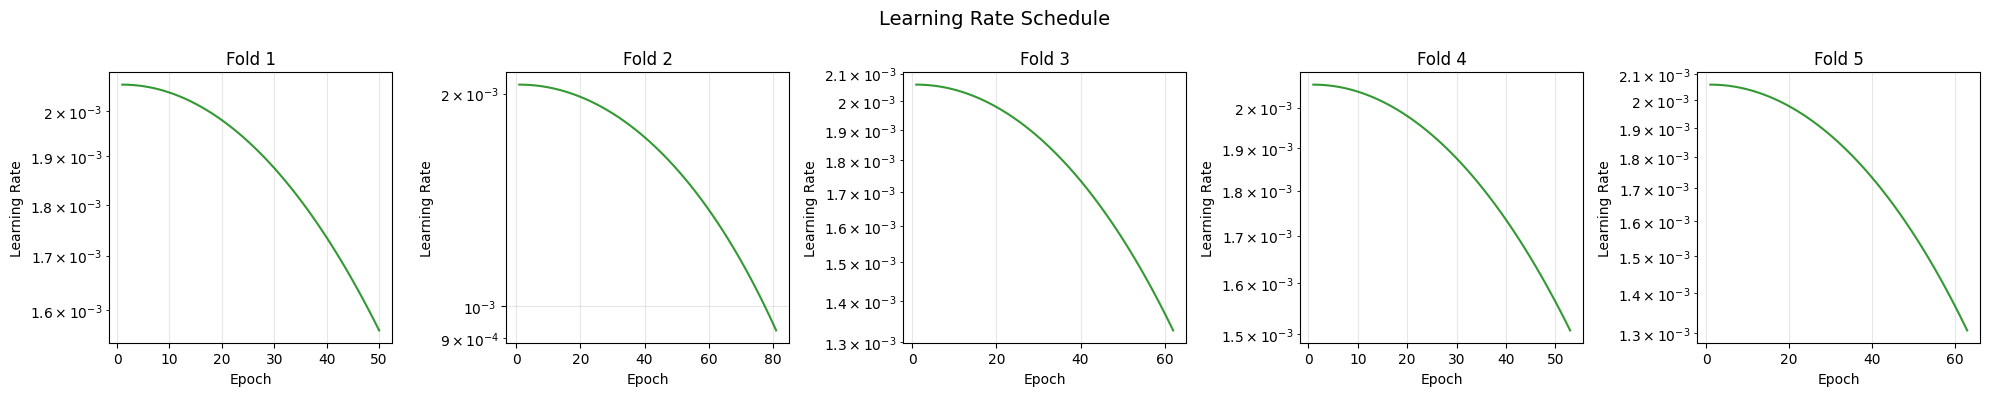

In [11]:
fig, axes = plt.subplots(1, N_FOLDS, figsize=(20, 4))
fig.suptitle('Learning Rate Schedule', fontsize=14)

for fold_idx, history in enumerate(all_histories):
    epochs = range(1, len(history['learning_rates']) + 1)
    axes[fold_idx].plot(epochs, history['learning_rates'], 'g-', alpha=0.8)
    axes[fold_idx].set_xlabel('Epoch')
    axes[fold_idx].set_ylabel('Learning Rate')
    axes[fold_idx].set_title(f'Fold {fold_idx + 1}')
    axes[fold_idx].grid(True, alpha=0.3)
    axes[fold_idx].set_yscale('log')

plt.tight_layout()
plt.savefig('learning_rate_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

## K-Fold Results Visualization

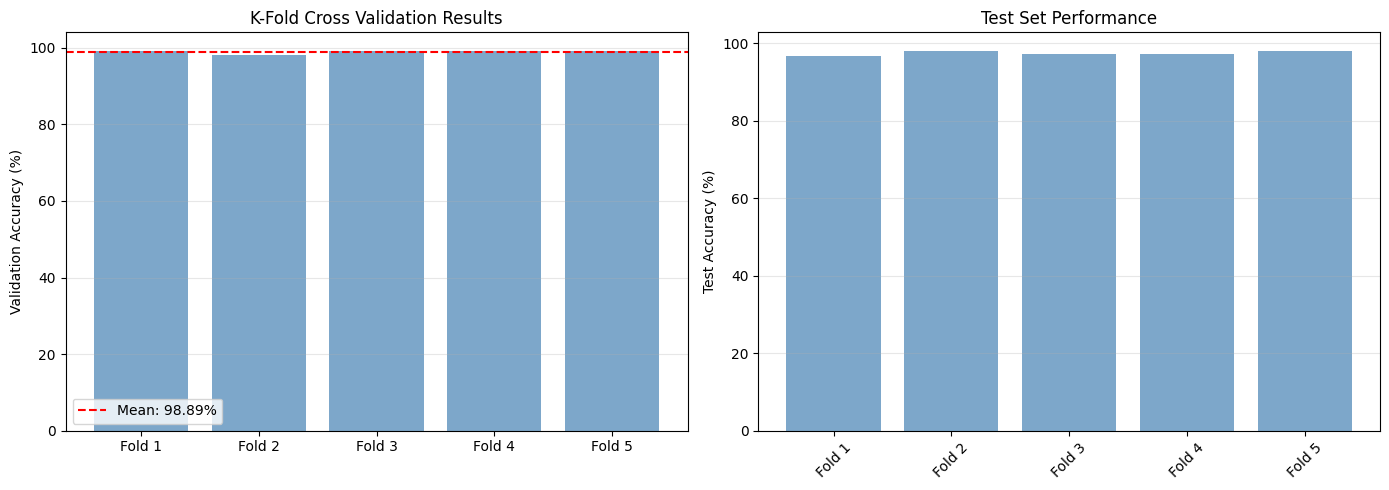


Summary Statistics:
Validation: 98.89% +/- 0.37%
Test (best fold): 97.96%


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# validation accuracies across folds
fold_nums = [f'Fold {i+1}' for i in range(N_FOLDS)]
ax1.bar(fold_nums, fold_results, color='steelblue', alpha=0.7)
ax1.axhline(y=mean_acc, color='r', linestyle='--', label=f'Mean: {mean_acc:.2f}%')
ax1.set_ylabel('Validation Accuracy (%)')
ax1.set_title('K-Fold Cross Validation Results')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# test accuracies
test_labels = [f'Fold {i+1}' for i in range(N_FOLDS)]
test_values = individual_test_accs
ax2.bar(test_labels, test_values, color='steelblue', alpha=0.7)
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Set Performance')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('kfold_results.png', dpi=150, bbox_inches='tight')
plt.show()

# summary stats
print("\nSummary Statistics:")
print(f"Validation: {mean_acc:.2f}% +/- {std_acc:.2f}%")
print(f"Test (best fold): {max(individual_test_accs):.2f}%")

## Confusion Matrix

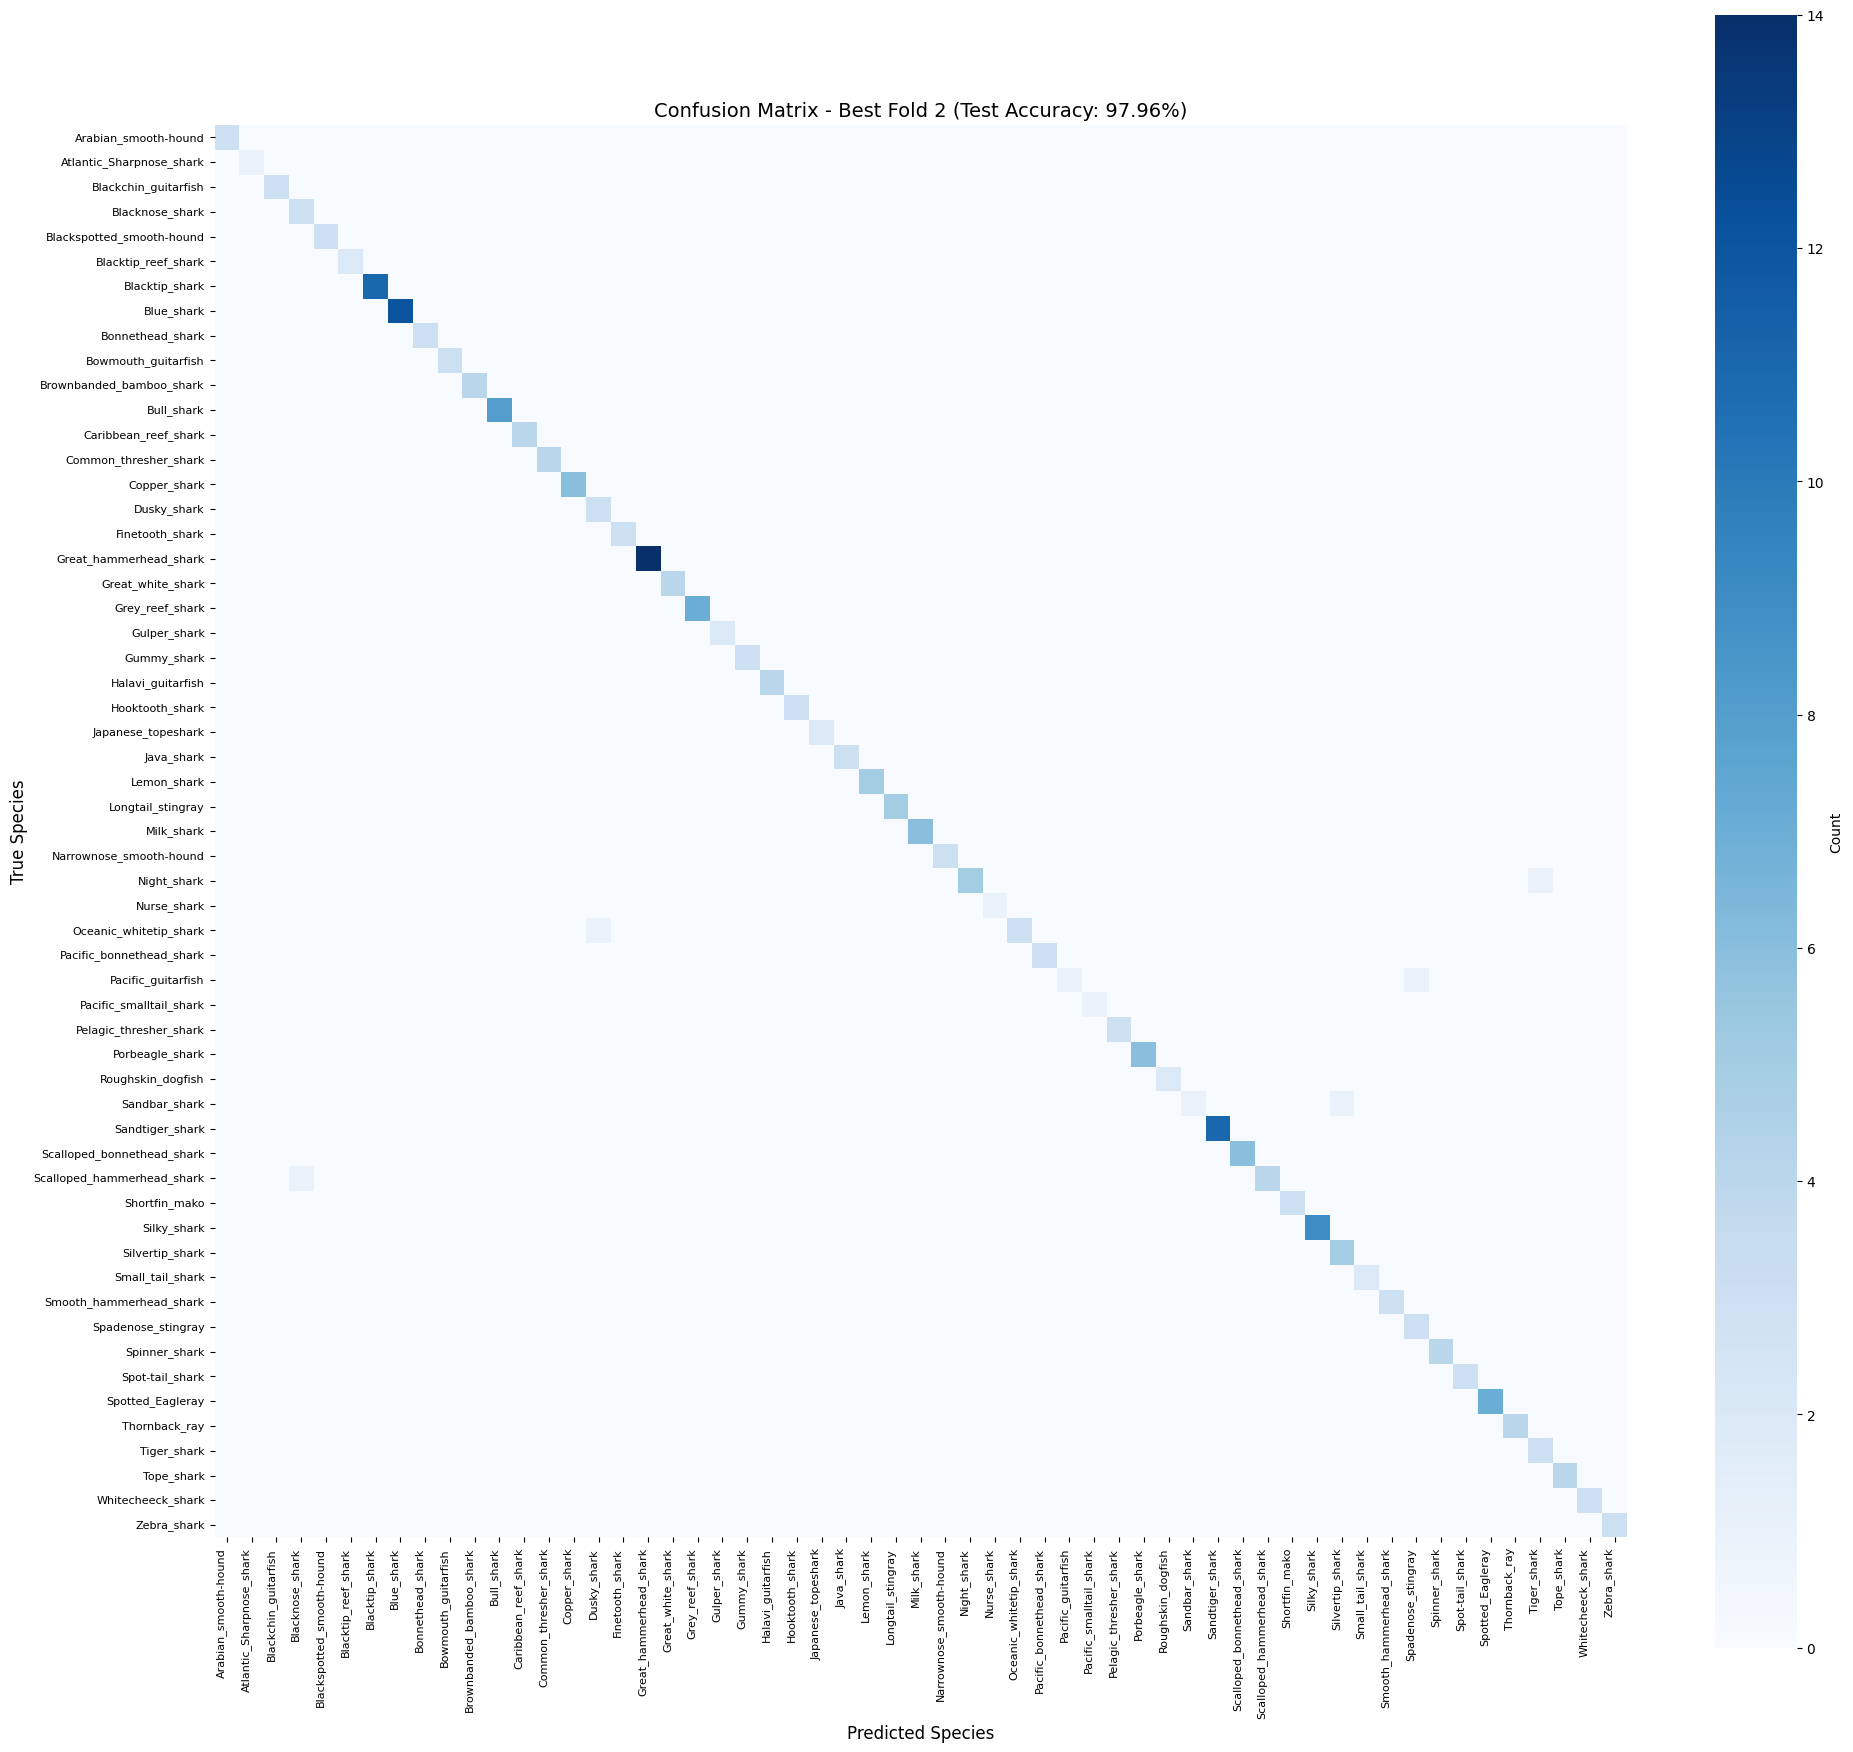


Total misclassifications: 5 out of 245
Error rate: 2.04%

Misclassified samples:
1. True: Night_shark                    -> Predicted: Tiger_shark
2. True: Oceanic_whitetip_shark         -> Predicted: Dusky_shark
3. True: Pacific_guitarfish             -> Predicted: Spadenose_stingray
4. True: Sandbar_shark                  -> Predicted: Silvertip_shark
5. True: Scalloped_hammerhead_shark     -> Predicted: Blacknose_shark


In [13]:
# test the best fold model and generate confusion matrix
best_model = get_model(num_classes).to(DEVICE)
import glob
model_files = glob.glob(f'efficientnet_b0_fold{best_test_fold+1}_*.pth')
checkpoint = torch.load(model_files[0], map_location=DEVICE)
best_model.load_state_dict(checkpoint['model_state_dict'])

test_acc, test_f1, test_precision, test_recall, preds, labels = test_model(best_model, test_loader, DEVICE)

# compute confusion matrix
cm = confusion_matrix(labels, preds)

# plot full confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, cmap='Blues', square=True, 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('True Species', fontsize=12)
plt.title(f'Confusion Matrix - Best Fold {best_test_fold+1} (Test Accuracy: {test_acc:.2f}%)', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()

# find misclassified samples
misclassified = []
for i, (true, pred) in enumerate(zip(labels, preds)):
    if true != pred:
        misclassified.append({
            'true': class_names[true],
            'predicted': class_names[pred]
        })

print(f"\nTotal misclassifications: {len(misclassified)} out of {len(labels)}")
print(f"Error rate: {100 * len(misclassified) / len(labels):.2f}%")

if len(misclassified) > 0:
    print("\nMisclassified samples:")
    for i, error in enumerate(misclassified, 1):
        print(f"{i}. True: {error['true']:30s} -> Predicted: {error['predicted']}")

## Per-Class Performance

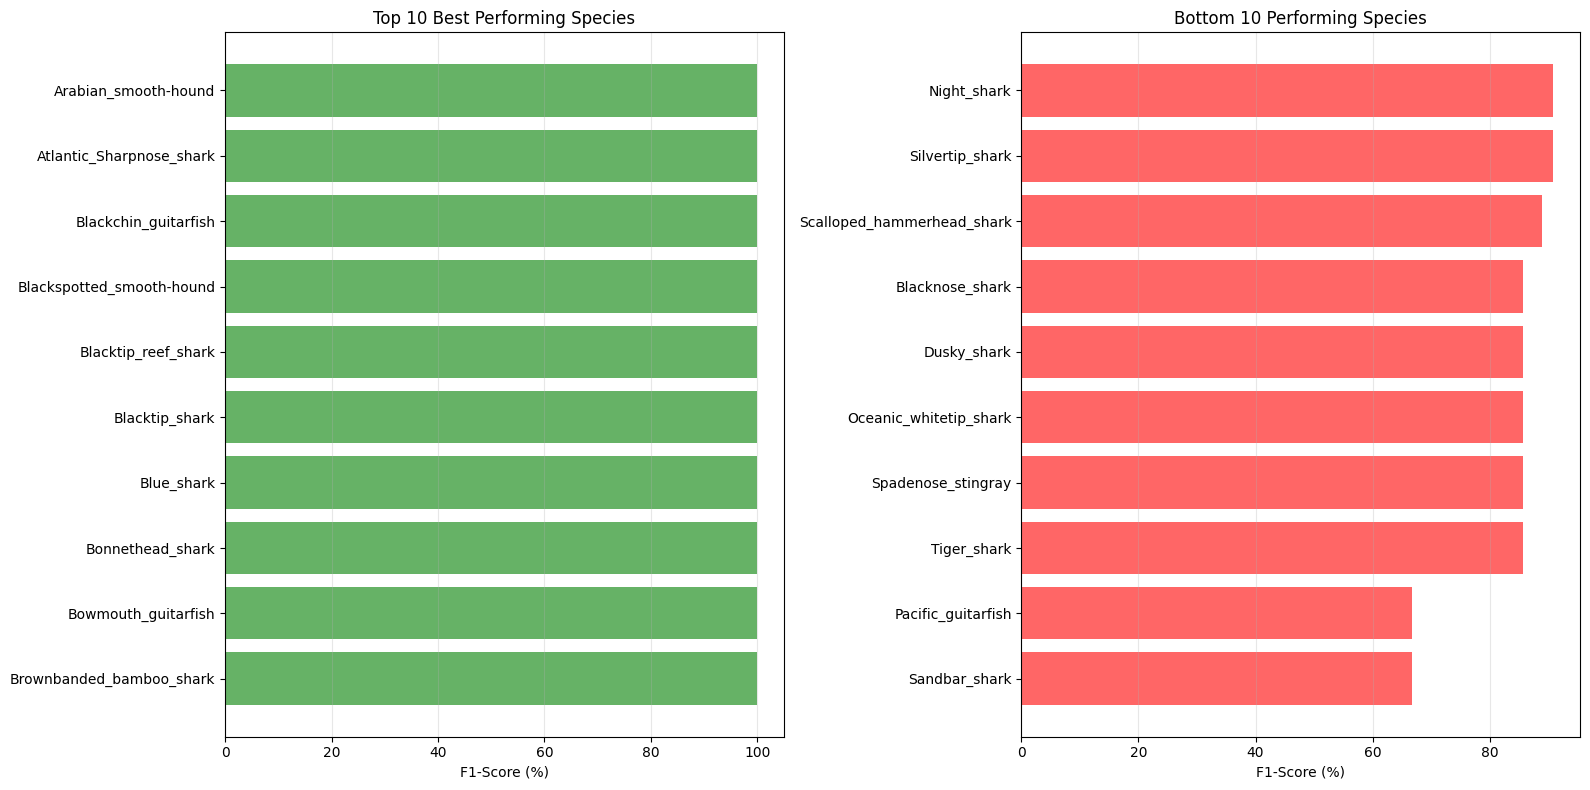


Per-Class Performance Metrics:

Class                               Precision    Recall       F1-Score     Support 
Arabian_smooth-hound                    100.00%     100.00%     100.00%      3
Atlantic_Sharpnose_shark                100.00%     100.00%     100.00%      1
Blackchin_guitarfish                    100.00%     100.00%     100.00%      3
Blackspotted_smooth-hound               100.00%     100.00%     100.00%      3
Blacktip_reef_shark                     100.00%     100.00%     100.00%      2
Blacktip_shark                          100.00%     100.00%     100.00%     11
Blue_shark                              100.00%     100.00%     100.00%     12
Bonnethead_shark                        100.00%     100.00%     100.00%      3
Bowmouth_guitarfish                     100.00%     100.00%     100.00%      3
Brownbanded_bamboo_shark                100.00%     100.00%     100.00%      4
Bull_shark                              100.00%     100.00%     100.00%      8
Caribbean_reef

In [14]:
# classification report for best fold
report = classification_report(labels, preds, target_names=class_names, output_dict=True, zero_division=0)

# extract per-class metrics
class_metrics = []
for class_name in class_names:
    if class_name in report:
        class_metrics.append({
            'class': class_name,
            'precision': report[class_name]['precision'] * 100,
            'recall': report[class_name]['recall'] * 100,
            'f1-score': report[class_name]['f1-score'] * 100,
            'support': report[class_name]['support']
        })

# sort by f1-score
class_metrics.sort(key=lambda x: x['f1-score'], reverse=True)

# plot top 10 and bottom 10 performing classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# top 10
top_10 = class_metrics[:10]
names_top = [m['class'] for m in top_10]
f1_top = [m['f1-score'] for m in top_10]
ax1.barh(names_top, f1_top, color='green', alpha=0.6)
ax1.set_xlabel('F1-Score (%)')
ax1.set_title('Top 10 Best Performing Species')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# bottom 10
bottom_10 = class_metrics[-10:]
names_bottom = [m['class'] for m in bottom_10]
f1_bottom = [m['f1-score'] for m in bottom_10]
ax2.barh(names_bottom, f1_bottom, color='red', alpha=0.6)
ax2.set_xlabel('F1-Score (%)')
ax2.set_title('Bottom 10 Performing Species')
ax2.grid(True, alpha=0.3, axis='x')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# print detailed metrics
print("\nPer-Class Performance Metrics:\n")
print(f"{'Class':<35} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<8}")
print("="*85)
for m in class_metrics:
    print(f"{m['class']:<35} {m['precision']:>10.2f}% {m['recall']:>10.2f}% {m['f1-score']:>10.2f}% {m['support']:>6.0f}")

print("\nOverall Metrics:")
print(f"Accuracy: {report['accuracy'] * 100:.2f}%")
print(f"Macro avg precision: {report['macro avg']['precision'] * 100:.2f}%")
print(f"Macro avg recall: {report['macro avg']['recall'] * 100:.2f}%")
print(f"Macro avg f1-score: {report['macro avg']['f1-score'] * 100:.2f}%")

## Training Summary Statistics

In [15]:
# gather final epoch stats for each fold
final_stats = []
for fold_idx, history in enumerate(all_histories):
    final_stats.append({
        'fold': fold_idx + 1,
        'final_train_loss': history['train_loss'][-1],
        'final_train_acc': history['train_acc'][-1],
        'final_val_loss': history['val_loss'][-1],
        'final_val_acc': history['val_acc'][-1],
        'best_val_acc': fold_results[fold_idx],
        'epochs_trained': len(history['train_loss']),
        'final_lr': history['learning_rates'][-1]
    })

print("\nTraining Summary by Fold:\n")
print(f"{'Fold':<6} {'Epochs':<8} {'Train Acc':<12} {'Val Acc':<12} {'Best Val':<12} {'Final LR':<12}")
print("="*70)
for stats in final_stats:
    print(f"{stats['fold']:<6} {stats['epochs_trained']:<8} "
          f"{stats['final_train_acc']:>10.2f}% {stats['final_val_acc']:>10.2f}% "
          f"{stats['best_val_acc']:>10.2f}% {stats['final_lr']:>10.2e}")

# convergence analysis
avg_epochs = np.mean([s['epochs_trained'] for s in final_stats])
print(f"\nAverage epochs until convergence: {avg_epochs:.1f}")
print(f"Min epochs: {min([s['epochs_trained'] for s in final_stats])}")
print(f"Max epochs: {max([s['epochs_trained'] for s in final_stats])}")


Training Summary by Fold:

Fold   Epochs   Train Acc    Val Acc      Best Val     Final LR    
1      50            98.61%      97.22%      99.07%   1.56e-03
2      81           100.00%      97.22%      98.15%   9.23e-04
3      62           100.00%      99.07%      99.07%   1.33e-03
4      53            99.30%      97.22%      99.07%   1.51e-03
5      63            99.54%      98.13%      99.07%   1.31e-03

Average epochs until convergence: 61.8
Min epochs: 50
Max epochs: 81


## Save Final Results

In [16]:
# compile all results
final_results = {
    'model': 'EfficientNet-B0',
    'hyperparameters': HYPERPARAMETERS,
    'configuration': {
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'focal_alpha': FOCAL_ALPHA,
        'focal_gamma': FOCAL_GAMMA,
        'mixup_alpha': MIXUP_ALPHA,
        'use_mixup': USE_MIXUP,
        'patience': PATIENCE,
        'n_folds': N_FOLDS,
        'random_seed': RANDOM_STATE
    },
    'cross_validation': {
        'fold_accuracies': [float(m['accuracy']) for m in fold_metrics],
        'fold_f1_scores': [float(m['f1']) for m in fold_metrics],
        'fold_precisions': [float(m['precision']) for m in fold_metrics],
        'fold_recalls': [float(m['recall']) for m in fold_metrics],
        'mean_accuracy': float(np.mean([m['accuracy'] for m in fold_metrics])),
        'std_accuracy': float(np.std([m['accuracy'] for m in fold_metrics])),
        'mean_f1': float(np.mean([m['f1'] for m in fold_metrics])),
        'mean_precision': float(np.mean([m['precision'] for m in fold_metrics])),
        'mean_recall': float(np.mean([m['recall'] for m in fold_metrics]))
    },
    'test_results': {
        'individual_fold_accuracies': [float(m['accuracy']) for m in individual_test_metrics],
        'individual_fold_f1_scores': [float(m['f1']) for m in individual_test_metrics],
        'individual_fold_precisions': [float(m['precision']) for m in individual_test_metrics],
        'individual_fold_recalls': [float(m['recall']) for m in individual_test_metrics],
        'best_fold': int(best_test_fold + 1),
        'best_test_accuracy': float(individual_test_metrics[best_test_fold]['accuracy']),
        'best_test_f1': float(individual_test_metrics[best_test_fold]['f1']),
        'best_test_precision': float(individual_test_metrics[best_test_fold]['precision']),
        'best_test_recall': float(individual_test_metrics[best_test_fold]['recall'])
    },
    'misclassified_samples': misclassified
}

# save to json
with open('efficientnet_final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Results saved to efficientnet_final_results.json")
print("="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print("\nCross-Validation Results:")
print(f"  Mean Accuracy: {final_results['cross_validation']['mean_accuracy']:.2f}% +/- {final_results['cross_validation']['std_accuracy']:.2f}%")
print(f"  Mean F1-Score: {final_results['cross_validation']['mean_f1']:.2f}%")
print(f"  Mean Precision: {final_results['cross_validation']['mean_precision']:.2f}%")
print(f"  Mean Recall: {final_results['cross_validation']['mean_recall']:.2f}%")

print(f"\nBest Fold (Fold {best_test_fold + 1}) Test Results:")
print(f"  Accuracy: {final_results['test_results']['best_test_accuracy']:.2f}%")
print(f"  F1-Score: {final_results['test_results']['best_test_f1']:.2f}%")
print(f"  Precision: {final_results['test_results']['best_test_precision']:.2f}%")
print(f"  Recall: {final_results['test_results']['best_test_recall']:.2f}%")

print(f"\nMisclassified: {len(misclassified)} / {len(labels)} samples")
print("="*70)

Results saved to efficientnet_final_results.json
FINAL RESULTS SUMMARY

Cross-Validation Results:
  Mean Accuracy: 98.89% +/- 0.37%
  Mean F1-Score: 98.57%
  Mean Precision: 98.39%
  Mean Recall: 98.89%

Best Fold (Fold 2) Test Results:
  Accuracy: 97.96%
  F1-Score: 97.89%
  Precision: 98.44%
  Recall: 97.96%

Misclassified: 5 / 245 samples
